# Midterm Project 4 (100 points total)

## In this project, you need to use unsupervised learning on genetic data: Reduce the dimensionality of the dataset with each feature as a genetic expression (DNA microarray) and then group the leukemia patients by K-means clustering.

### Import the necessary libraries. (5 points)

In [1]:
#Import the necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

### Upload the data and preprocess it. (10 points)

In [2]:
# Upload the data to a Dataframe.
data = pd.read_csv('gene_expression_data.csv')
data = pd.DataFrame(data)


In [3]:
# Note that some columns have non-numeric information which we do not need for our models. Discard those columns.
# Hint: You can use indexing (much faster) or a loop.

call_index = np.linspace(3,77, num=38).astype(int)
data = data.drop(columns=data.columns[call_index])


In [4]:


# Transpose the dataset so that each patient is in a row.
X = data.T
# Get rid of the headers which are not needed for numeric analysis.
X = X.drop(['Gene Description','Gene Accession Number'],axis=0)
X.index = pd.to_numeric(X.index)


In [5]:
X


,0,1,2,3,4,5,6,7,8,9,...,7119,7120,7121,7122,7123,7124,7125,7126,7127,7128
1,-214,-153,-58,88,-295,-558,199,-176,252,206,...,185,511,-125,389,-37,793,329,36,191,-37
2,-139,-73,-1,283,-264,-400,-330,-168,101,74,...,169,837,-36,442,-17,782,295,11,76,-14
3,-76,-49,-307,309,-376,-650,33,-367,206,-215,...,315,1199,33,168,52,1138,777,41,228,-41
4,-135,-114,265,12,-419,-585,158,-253,49,31,...,240,835,218,174,-110,627,170,-50,126,-91
5,-106,-125,-76,168,-230,-284,4,-122,70,252,...,156,649,57,504,-26,250,314,14,56,-25
6,-138,-85,215,71,-272,-558,67,-186,87,193,...,115,1221,-76,172,-74,645,341,26,193,-53
7,-72,-144,238,55,-399,-551,131,-179,126,-20,...,30,819,-178,151,-18,1140,482,10,369,-42
8,-413,-260,7,-2,-541,-790,-275,-463,70,-169,...,289,629,-86,302,23,1799,446,59,781,20
9,5,-127,106,268,-210,-535,0,-174,24,506,...,356,980,6,177,-12,758,385,115,244,-39
10,-88,-105,42,219,-178,-246,328,-148,177,183,...,42,986,26,101,21,570,359,9,171,7


In [6]:
# Lastly, scale the dataset. You can use any type of scaling (implemented or from a library) we have covered in class.

scaler = MinMaxScaler()
scaler.fit(X)
X = scaler.transform(X)

### Apply Principle Component Analysis (PCA) to the preprocessed dataset to reduce its dimensionality. (10 points)

In [7]:
# Create a PCA object that would preserve 98% of the variance in the dataset.
pca = PCA(0.98)

# # Transform the data.
X_pca = pca.fit_transform(X)


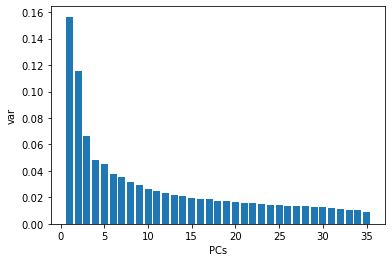

In [8]:
plt.bar(range(1,X_pca.shape[1]+1), pca.explained_variance_ratio_)
plt.xlabel('PCs')
plt.ylabel('var')
plt.show()

### Question 1: You cannot apply PCA for more than 38 dimensions, even though the dimensionality of the original data is way higher than that. (You can try and see for yourself.) What is the reason for this? (10 points)

#### The reason is that 38 is the number of samples in the dataset and the lower value between the number of samples and the numbers of dimensions and you cannot apply PCA for more than the smaller number between those two  values.

### Create a new PCA object that reduces the dimensionality of the dataset to 2. Then, apply K-means clustering to the two-dimensional data and find the number of clusters that you think is best. (Using a heuristic method we have covered in class.)  (25 points)

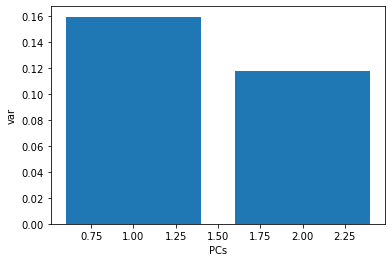

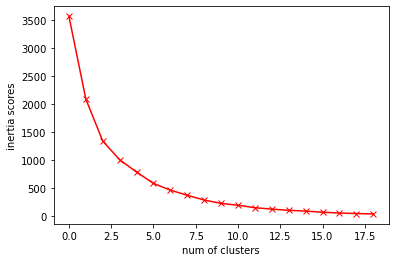

In [10]:
# Create a new PCA object that creates a two-dimensional dataset.
pca1 = PCA(n_components=2, svd_solver='full')

# Reduce the dimensionality of the dataset and print the variance captured by this new 2-dim dataset.
X2_pca = pca1.fit_transform(X_pca)
plt.bar(range(1,X2_pca.shape[1]+1), pca1.explained_variance_ratio_)
plt.xlabel('PCs')
plt.ylabel('var')
plt.show()

# Apply K-Means clustering from 1 to 20 clusters. Plot the inertia graph for all K values.
scores = []# 

for ii in range(1,20):
    kmeans = KMeans(n_clusters=ii)
    kmeans.fit(X2_pca)
    scores.append(kmeans.inertia_)
    
    
#Plotting the plot for elbow rule
plt.plot(scores, '-rx')
plt.xlabel('num of clusters')
plt.ylabel('inertia scores')
plt.show()


# Pick the K value that you think is best; create a K-means object with that value and extract the cluster labels.
# kmeans_best = KMeans(n_clusters=5, random_state=42)
# kmeans_best.fit(X2_pca)
# cluster_labels = kmeans_best.labels_

# Plot the two-dimensional dataset, color coding different clusters.


In [11]:
# scores = []# 

# for ii in range(1,20):
#     kmeans = KMeans(n_clusters=ii)
#     kmeans.fit(X_pca)
#     scores.append(kmeans.inertia_)
    
    
# #Plotting the plot for elbow rule
# plt.plot(scores, '-rx')
# plt.show()



# kmeans_best = KMeans(n_clusters=5, random_state=42)
# kmeans_best.fit(X_pca)
# cluster_labels = kmeans_best.labels_




In [12]:
# kmeans_best = KMeans(n_clusters=3, random_state=42)
# kmeans_best.fit(X2_pca)
# cluster_labels = kmeans_best.labels_

# plt.figure(figsize=(8,6))
# sns.scatterplot(x=X2_pca[:,0], y=X2_pca[:,1], hue=cluster_labels)
# plt.legend()
# plt.show()

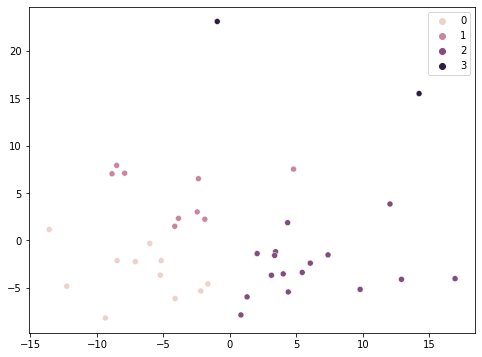

In [13]:
# Pick the K value that you think is best; create a K-means object with that value and extract the cluster labels.
kmeans_best = KMeans(n_clusters=4, random_state=42)
kmeans_best.fit(X2_pca)
cluster_labels = kmeans_best.labels_

# Plot the two-dimensional dataset, color coding different clusters.
plt.figure(figsize=(8,6))
sns.scatterplot(x=X2_pca[:,0], y=X2_pca[:,1], hue=cluster_labels)
plt.legend()
plt.show()

In [14]:
# kmeans_best = KMeans(n_clusters=5, random_state=42)
# kmeans_best.fit(X2_pca)
# cluster_labels = kmeans_best.labels_

# plt.figure(figsize=(8,6))
# sns.scatterplot(x=X2_pca[:,0], y=X2_pca[:,1], hue=cluster_labels)
# plt.legend()
# plt.show()

In [15]:
# kmeans_best = KMeans(n_clusters=6, random_state=42)
# kmeans_best.fit(X2_pca)
# cluster_labels = kmeans_best.labels_

# plt.figure(figsize=(8,6))
# sns.scatterplot(x=X2_pca[:,0], y=X2_pca[:,1], hue=cluster_labels)
# plt.legend()
# plt.show()

### Question 2: What do you see in the clustered data plot? Interpret the output, keeping in mind the amount of variance captured by the low-dimensional dataset and the shortcomings of K-means clustering. (15 points)

#### In the clustered data plot, you can see the data clustered based on how many clusters we pass to the K-means function. 4 clusters appears to have the best fit for the clusters but it does not address the visible outliers seen on the plot very well. These outliers simply get lumped in a cluster of their own as the algorithms see fit. This reduced dataset also captures less than 30% of the variance in the full dataset which is going to affect the performance of our model. Another shortcoming is that we have to specify the number of clusters based on visual interpretation of the elbow graph

### Lastly, use the dataset that captures 98% of the variance of the original data and apply K-means clustering to it. Using the same heuristic method, find the best number of clusters. (10 points)

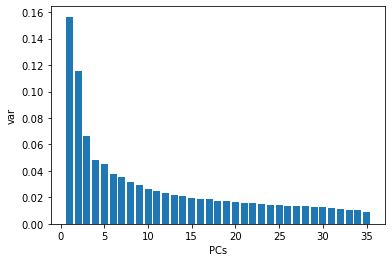

In [16]:
plt.bar(range(1,X_pca.shape[1]+1), pca.explained_variance_ratio_)
plt.xlabel('PCs')
plt.ylabel('var')
plt.show()

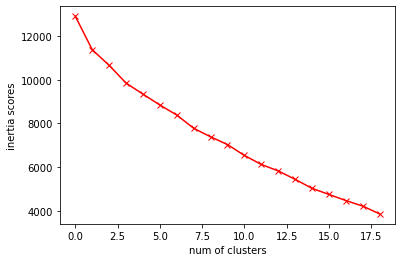

In [9]:
# Apply K-Means clustering from 1 to 20 clusters. Plot the inertia graph for all values.
scores1 = []

for ii in range(1,20):
    kmeans = KMeans(n_clusters=ii)
    kmeans.fit(X_pca)
    scores1.append(kmeans.inertia_)
    
    
#Plotting the plot for elbow rule
plt.plot(scores1, '-rx')
plt.xlabel('num of clusters')
plt.ylabel('inertia scores')
plt.show()


# Print the optimum number of clusters.


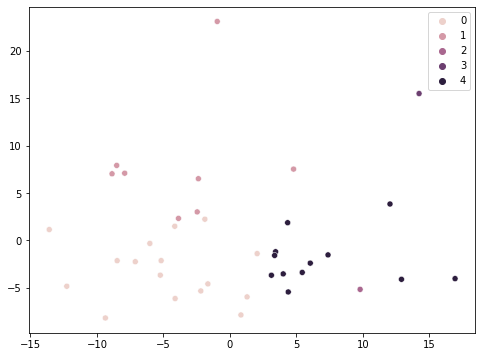

In [18]:
kmeans_best = KMeans(n_clusters=5, random_state=42)
kmeans_best.fit(X_pca)
cluster_labels = kmeans_best.labels_

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels)
plt.legend()
plt.show()

### Question 3: What is the best number of clusters? Can we visualize these clusters? What does all this tell about using K-means clustering method for high-dim data? What would you propose to improve the clustering results? (15 points)

##### Using 5 clusters appears to give the best results with 5 reasonable clusters being almost discernible. Even though the clusters are discernable, they are some parts that overlap which make it difficult to visualize the clusters. This is expected given that there is no clearly visible elbow in the inertia graph of this dataset. It implies the K-means clustering is struggling to capture the information present in higher dimensionality data.  K-means clustering also struggles with outliers and there a few visual outliers in the scatterplot. To improve the clustering results, I would get rid of the outliers and try reducing dimensionality as much as possible without losing too much variance. It might also be better to use other clustering methods such as DBSCAN that handle outliers better.